In [27]:
import numpy as np
from src.plot import plot_images_numpy
from pathlib import Path
from PIL import Image

## Visualization

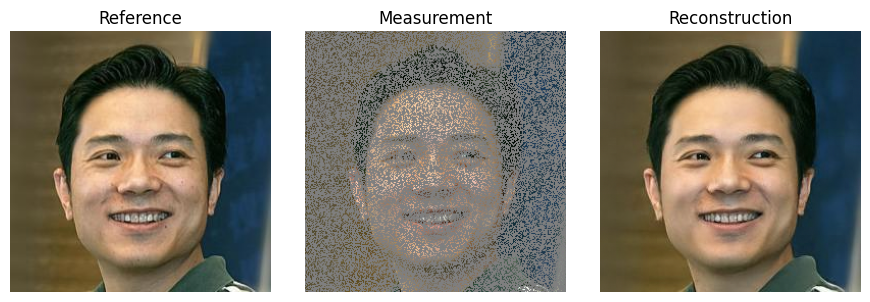

In [25]:
TASK    = "inpainting"
MODEL   = "celeba"
DATASET = "celeba"
SAVE_PATH = "dps_result"

i = 0
ref_img = Image.open(Path('data') / DATASET / f"{i:05d}.png" ).convert("RGB")
ref_img_np = np.array(ref_img).transpose(2,0,1)/255.0
ref_img_np = ref_img_np[None, ...]

recon_path = Path(SAVE_PATH) / MODEL / DATASET / TASK / "recon" / f"{i:05d}_recon.npy"
recon_img_np = np.load(recon_path)

measure_path = Path(SAVE_PATH) / MODEL / DATASET / TASK / "measure" / f"{i:05d}_measure.npy"
measure_img_np = ((np.load(measure_path)+1)/2).clip(0,1)

plot_images_numpy(
    np.concatenate([ref_img_np, measure_img_np, recon_img_np], axis=0),
    titles = ["Reference", "Measurement", "Reconstruction"], show = True
)

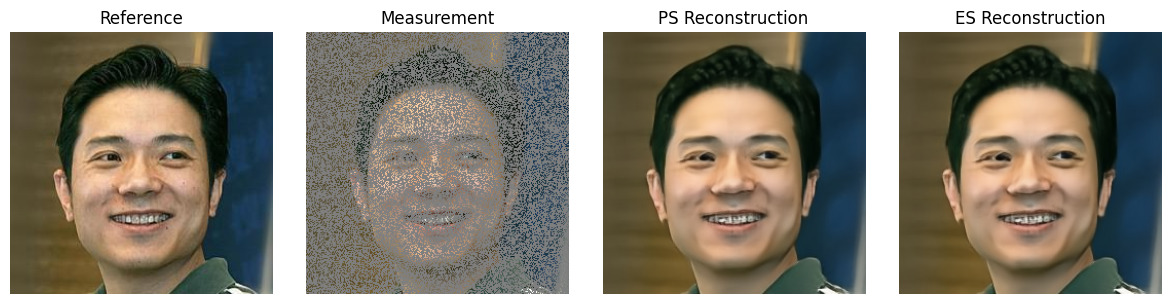

In [26]:
TASK    = "inpainting"
MODEL   = "church"
DATASET = "celeba"
SAVE_PATH = "weak_result"

i = 0
ref_img = Image.open(Path('data') / DATASET / f"{i:05d}.png" ).convert("RGB")
ref_img_np = np.array(ref_img).transpose(2,0,1)/255.0
ref_img_np = ref_img_np[None, ...]

ps_recon_path = Path(SAVE_PATH) / MODEL / DATASET / TASK / "recon" / f"{i:05d}_ps_recon.npy"
ps_recon_img_np = np.load(ps_recon_path)

es_recon_path = Path(SAVE_PATH) / MODEL / DATASET / TASK / "recon" / f"{i:05d}_es_recon.npy"
es_recon_img_np = np.load(es_recon_path)

measure_path = Path(SAVE_PATH) / MODEL / DATASET / TASK / "measure" / f"{i:05d}_measure.npy"
measure_img_np = ((np.load(measure_path)+1)/2).clip(0,1)

plot_images_numpy(
    np.concatenate([ref_img_np, measure_img_np, ps_recon_img_np, es_recon_img_np], axis=0),
    titles = ["Reference", "Measurement", "PS Reconstruction", "ES Reconstruction"], show = True
)

## Metric Load

In [49]:
TASK    = "inpainting"
MODEL   = "celeba"
DATASET = "celeba"
SAVE_PATH = "dps_result"
i = 0
print( f"DPS Results: using {MODEL} reconstruct {DATASET}" )
metric = np.load(Path(SAVE_PATH) / MODEL / DATASET / TASK / 'recon' / f"{i:05d}_metrics.npz")
print(metric['final_psnr'], metric['final_ssim'], metric['final_lpips'])

DPS Results: using celeba reconstruct celeba
31.669557571411133 0.893744819089023 0.14083705842494965


In [50]:
TASK    = "inpainting"
MODEL   = "church"
DATASET = "celeba"
SAVE_PATH = "weak_result"
i = 0
print( f"Weak Results: using {MODEL} reconstruct {DATASET}" )
metric = np.load(Path(SAVE_PATH) / MODEL / DATASET / TASK / 'recon' / f"{i:05d}_metrics.npz")
print(metric['es_final_psnr'], metric['es_final_ssim'], metric['es_final_lpips'])

Weak Results: using church reconstruct celeba
31.454082489013672 0.8961854426006496 0.19425146281719208


In [51]:
TASK    = "inpainting"
MODEL   = "celeba"
DATASET = "celeba"
SAVE_PATH = "dmplug_result"
i = 0
print( f"DM-Plug Results: using {MODEL} reconstruct {DATASET}" )
metric = np.load(Path(SAVE_PATH) / MODEL / DATASET / TASK / 'recon' / f"{i:05d}_metrics.npz")
print(metric['es_final_psnr'], metric['es_final_ssim'], metric['es_final_lpips'])

DM-Plug Results: using celeba reconstruct celeba
31.38345718383789 0.8795521296298745 0.22527574002742767
